# Seminário de Sondagens Atmosféricas
### Análise e Comparação de Três Regimes de Estabilidade: Estável, Neutro e Instável

Processamento termodinâmico, cálculo de índices de instabilidade e cisalhamento, e modelagem de parcelas (Kerry Emanuel) para três regimes atmosféricos:
1. Compilação do modelo de Emanuel (`wyoming.f`)
2. Definição e obtenção dos dados das três sondagens (`CASOS`)
3. Tabela comparativa e conferência com índices do Wyoming
4. Diagramas Skew-T Log-P e Hodógrafos individuais por caso
5. Comparação dos Perfis Verticais ($\theta$, $\theta_e$, $\theta_{es}$)
6. Estabilidade estática ($N^2$ e parâmetro $S$)
7. Matrizes de flutuabilidade de Emanuel (processos reversível e pseudoadiabático)
8. Síntese dos resultados

In [1]:
# Instalação de dependências (só instala o que faltar; fora do Colab instale antes:
#   uv pip install metpy siphon   ou   conda install -c conda-forge metpy siphon)
import importlib.util, sys
if any(importlib.util.find_spec(m) is None for m in ('metpy', 'siphon')):
    !{sys.executable} -m pip install -q metpy siphon

import os, sys, shutil, subprocess, urllib.request, re
from datetime import datetime
import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
from matplotlib import transforms
%matplotlib inline

import siphon
from siphon.simplewebservice.wyoming import WyomingUpperAir
import metpy
import metpy.calc as mpcalc
from metpy.units import units
from metpy.plots import Hodograph, SkewT
from IPython.display import display, Markdown

# Pasta onde ficam as figuras e a tabela de índices usadas no site (index.html) e nos slides
PASTA_SAIDA = 'metpack'
os.makedirs(PASTA_SAIDA, exist_ok=True)
URL_REPOSITORIO = 'https://raw.githubusercontent.com/reinaldohaas/tarefa-meso/master/metpack'

print(f"Siphon: {siphon.__version__}")
print(f"MetPy: {metpy.__version__}")
print(f"Pandas: {pd.__version__}")

Siphon: 0.11.0
MetPy: 1.7.1
Pandas: 3.0.6


### 1. Compilação do Programa Fortran de Kerry Emanuel (`wyoming.f`)

O programa `wyoming.f` calcula a evolução da flutuabilidade de parcelas de ar levantadas a partir de múltiplos níveis de pressão até o topo da troposfera:
* Download automático do código fonte original caso não esteja presente no diretório.
* Opção `CORTE_EMANUEL = False` para não truncar valores negativos de flutuabilidade em $-4\text{ K}$, permitindo avaliar a magnitude real da inibição convectiva.
* Compilação com a diretiva `-static` para vincular estaticamente as rotinas de tempo de execução do compilador.

In [2]:
# Download do código fonte se necessário
if not os.path.exists('wyoming.f'):
    for url_f in ['https://texmex.mit.edu/pub/emanuel/soundings/wyoming.f',   # original (MIT)
                  f'{URL_REPOSITORIO}/wyoming.f']:                          # cópia da disciplina
        try:
            urllib.request.urlretrieve(url_f, 'wyoming.f')
            if 'PROGRAM' in open('wyoming.f', encoding='latin1').read(3000).upper():
                print('wyoming.f obtido de', url_f)
                break
        except Exception as e:
            print('falhou', url_f, '->', e)
    else:
        raise FileNotFoundError('Não foi possível obter o wyoming.f; faça upload de metpack/wyoming.f do repositório.')

CORTE_EMANUEL = False
with open('wyoming.f', 'r', encoding='latin1') as f:
    codigo_fortran = f.read()

if not CORTE_EMANUEL:
    for l in ['TRDBAR(I,J)=MAX(TRDBAR(I,J),-4.0)', 'TPDBAR(I,J)=MAX(TPDBAR(I,J),-4.0)']:
        if l in codigo_fortran:
            codigo_fortran = codigo_fortran.replace(l, 'CONTINUE')

with open('wyoming_usado.f', 'w', encoding='latin1') as f:
    f.write(codigo_fortran)

# Detecção do compilador Fortran
gfortran_bin = shutil.which('gfortran')
if not gfortran_bin and os.name == 'nt':
    candidatos = [
        r'C:\Users\haas\miniforge3\Library\bin\gfortran.exe',
        r'C:\Users\haas\miniforge3\envs\py312\Library\bin\gfortran.exe',
        os.path.expanduser(r'~\miniforge3\Library\bin\gfortran.exe'),
        os.path.expanduser(r'~\miniforge3\envs\py312\Library\bin\gfortran.exe'),
    ]
    for c in candidatos:
        if os.path.exists(c):
            gfortran_bin = c
            break

if not gfortran_bin:
    raise FileNotFoundError("Compilador gfortran não encontrado.")

bin_dir = os.path.dirname(gfortran_bin)
if bin_dir not in os.environ.get('PATH', ''):
    os.environ['PATH'] = bin_dir + os.pathsep + os.environ.get('PATH', '')

cmd_compila = [gfortran_bin, '-O2', '-static', '-o', 'wyoming.exe', 'wyoming_usado.f']
res = subprocess.run(cmd_compila, capture_output=True, text=True)
if res.returncode != 0:
    # -static não funciona no macOS nem em alguns gfortran do conda: tenta sem ele
    res = subprocess.run([a for a in cmd_compila if a != '-static'], capture_output=True, text=True)
if res.returncode != 0:
    raise RuntimeError(f"Falha na compilação:\n{res.stderr}")
print("wyoming.exe compilado com sucesso.")

wyoming.exe compilado com sucesso.


### 2. Definição e Obtenção dos Três Casos (`CASOS`)

**Dados:** Siphon (`siphon.simplewebservice.wyoming.WyomingUpperAir`), que baixa a sondagem da Universidade de Wyoming. **Cálculo:** MetPy. Se o Wyoming não responder, são usadas cópias salvas na pasta ou as cópias guardadas no repositório (`metpack/`). A fonte usada é sempre impressa.
* **ESTÁVEL:** 12/12/1995 12:00 UTC (Estação 83971).
* **NEUTRA:** 22/12/1995 12:00 UTC (Estação 83971).
* **INSTÁVEL:** 24/12/1995 12:00 UTC (Estação 83971).

In [3]:
CASOS = [
    dict(regime='ESTÁVEL',  station='83971', date=datetime(1995, 12, 12, 12), src='FM35'),
    dict(regime='NEUTRA',   station='83971', date=datetime(1995, 12, 22, 12), src='FM35'),
    dict(regime='INSTÁVEL', station='83971', date=datetime(1995, 12, 24, 12), src='FM35'),
]

def url_wyoming(station, date, src, tipo):
    return ('https://weather.uwyo.edu/wsgi/sounding?datetime='
            f'{date:%Y-%m-%d}%20{date:%H:%M:%S}&id={station}&src={src}&type={tipo}')

def le_tabela_wyoming(texto):
    linhas = re.sub(r'<[^>]+>', '', texto).splitlines()
    i0 = next(i for i, l in enumerate(linhas) if 'PRES' in l and 'HGHT' in l)
    nomes = linhas[i0].split()
    fins = [m.end() for m in re.finditer(r'\S+', linhas[i0])]
    k = i0 + 1
    while k < len(linhas) and (not linhas[k].strip() or linhas[k].strip().startswith('-') or 'hPa' in linhas[k]):
        k += 1
    regs = []
    for l in linhas[k:]:
        if not l.strip() or not re.match(r'^\s*-?\d', l):
            break
        ini = 0; vals = []
        for fim in fins:
            campo = l[ini:fim].strip(); ini = fim
            vals.append(float(campo) if campo else np.nan)
        regs.append(vals)
    t = pd.DataFrame(regs, columns=nomes)
    # Velocidade sempre em NÓS: SKNT (formato antigo) já está em nós; SPED (formato atual) está em m/s
    vel_kt = t['SKNT'] if 'SKNT' in t.columns else t['SPED'] * 1.943844
    df = pd.DataFrame({
        'pressure': t['PRES'], 'height': t['HGHT'], 'temperature': t['TEMP'],
        'dewpoint': t['DWPT'], 'direction': t['DRCT'], 'speed': vel_kt
    })
    return df

def le_indices_wyoming(texto):
    ind = {}
    matches = re.findall(r'<TD[^>]*>\s*([A-Za-z0-9_]+)\s*</TD>\s*<TD[^>]*>\s*([^<]+?)\s*</TD>\s*<TD[^>]*>\s*(-?\d+(?:\.\d+)?)\s*</TD>', texto or '')
    for m in matches:
        ind[m[0].strip()] = float(m[2])
    return ind

def busca_wyoming(station, date, src='FM35'):
    arq_csv = f'wyoming_{station}_{date:%Y%m%d_%H}Z.csv'
    arq_tab = f'wyoming_{station}_{date:%Y%m%d_%H}Z.txt'
    arq_ind = f'wyoming_indices_{station}_{date:%Y%m%d_%H}Z.txt'
    df = None
    fonte = None
    
    # 1. Obtenção primária dos dados via Siphon
    try:
        df = WyomingUpperAir.request_data(date, station)
        fonte = 'Siphon (WyomingUpperAir)'
        df.to_csv(arq_csv, index=False)
    except Exception:
        if os.path.exists(arq_csv):
            df = pd.read_csv(arq_csv)
            fonte = f'cópia salva CSV {arq_csv}'
        elif os.path.exists(arq_tab):
            df = le_tabela_wyoming(open(arq_tab, encoding='utf-8').read())
            fonte = f'cópia salva TXT {arq_tab}'
        else:
            for url_t, nome_f in [(url_wyoming(station, date, src, 'TEXT:LIST'), 'Wyoming TEXT:LIST'),
                                  (f'{URL_REPOSITORIO}/sounding_{date:%Y%m%d_%H}Z.txt', 'cópia do repositório')]:
                try:
                    r = requests.get(url_t, timeout=60)
                    r.raise_for_status()
                    df = le_tabela_wyoming(r.text)
                    fonte = f'{nome_f}: {url_t}'
                    open(arq_tab, 'w', encoding='utf-8').write(r.text)
                    break
                except Exception as e:
                    print(f'  falhou {nome_f}: {type(e).__name__}')
            if df is None:
                raise RuntimeError(f'Sem dados de {station} em {date:%Y-%m-%d %HZ} (Siphon, cópias salvas, Wyoming e repositório falharam).')

    # 2. Obtenção dos índices reportados pelo servidor Wyoming (type=INDICES)
    ind_txt = None
    try:
        r = requests.get(url_wyoming(station, date, src, 'INDICES'), timeout=60)
        r.raise_for_status()
        ind_txt = r.text
        open(arq_ind, 'w', encoding='utf-8').write(ind_txt)
    except Exception:
        if os.path.exists(arq_ind):
            ind_txt = open(arq_ind, encoding='utf-8').read()
        else:
            try:
                r = requests.get(f'{URL_REPOSITORIO}/indices_{date:%Y%m%d_%H}Z.txt', timeout=60)
                r.raise_for_status()
                ind_txt = r.text
                open(arq_ind, 'w', encoding='utf-8').write(ind_txt)
            except Exception:
                pass
    indices_wyo = le_indices_wyoming(ind_txt) if ind_txt else {}
    return df, fonte, indices_wyo

def limpa_sondagem(df):
    df = (df.dropna(subset=['pressure', 'temperature', 'dewpoint', 'height'])
            .sort_values('pressure', ascending=False).drop_duplicates('pressure').reset_index(drop=True))
    if 'u_wind' not in df.columns or 'v_wind' not in df.columns or df['u_wind'].isnull().all():
        u = np.full(len(df), np.nan)
        v = np.full(len(df), np.nan)
        has_wind = df['speed'].notnull() & df['direction'].notnull()
        if has_wind.any():
            u_val, v_val = mpcalc.wind_components(df.loc[has_wind, 'speed'].values * units.knots,
                                                  df.loc[has_wind, 'direction'].values * units.degrees)
            u[has_wind] = u_val.to('m/s').m      # guardados em m/s
            v[has_wind] = v_val.to('m/s').m
        df['u_wind'], df['v_wind'] = u, v
    return df

def escreve_sounding_txt(df, station, date, arquivo='sounding.txt'):
    with open(arquivo, 'w', encoding='latin1') as f:
        f.write('\n' * 10)
        for _, r in df.iterrows():
            f.write(f"{r['pressure']:7.1f}{r['height']:7.0f}{r['temperature']:7.1f}{r['dewpoint']:7.1f}\n")
        f.write('</PRE>\n')
        f.write(f'Station identifier: {station}\n')
        f.write(f'Station number: {station}\n')
        f.write(f'Observation time: {date:%y%m%d} {date:%H%M}\n')

In [4]:
def calcula_caso(c):
    d, c['fonte'], c['indices_wyoming'] = busca_wyoming(c['station'], c['date'], c['src'])
    df = limpa_sondagem(d)
    c['df'] = df
    c['rotulo'] = f"{c['regime']}: {c['station']} {c['date']:%d/%m/%Y %HZ}"

    p = df['pressure'].values * units.hPa
    T = df['temperature'].values * units.degC
    Td = df['dewpoint'].values * units.degC
    z = df['height'].values * units.meter
    h = z - z[0]
    u = df['u_wind'].values * units('m/s')
    v = df['v_wind'].values * units('m/s')

    # Perfis e parcelas
    prof_sb = mpcalc.parcel_profile(p, T[0], Td[0]).to('degC')
    cape_sb, cin_sb = mpcalc.surface_based_cape_cin(p, T, Td)
    
    p_ml, T_ml, Td_ml = mpcalc.mixed_parcel(p, T, Td, depth=100 * units.hPa)
    prof_ml = mpcalc.parcel_profile(p, T_ml, Td_ml).to('degC')
    cape_ml, cin_ml = mpcalc.mixed_layer_cape_cin(p, T, Td, depth=100 * units.hPa)
    
    cape_mu, cin_mu = mpcalc.most_unstable_cape_cin(p, T, Td)
    p_mu, T_mu, Td_mu, i_mu = mpcalc.most_unstable_parcel(p, T, Td)
    prof_mu = mpcalc.parcel_profile(p[i_mu:], T_mu, Td_mu).to('degC')

    lcl_sb = mpcalc.lcl(p[0], T[0], Td[0])
    lfc_sb = mpcalc.lfc(p, T, Td, prof_sb)
    el_sb = mpcalc.el(p, T, Td, prof_sb)

    lcl_ml = mpcalc.lcl(p_ml, T_ml, Td_ml)
    lfc_ml = mpcalc.lfc(p, T, Td, prof_ml)
    el_ml = mpcalc.el(p, T, Td, prof_ml)

    pwat = mpcalc.precipitable_water(p, Td)

    def tenta(f):
        try: return f()
        except Exception: return np.nan

    li = tenta(lambda: mpcalc.lifted_index(p, T, prof_sb)[0].m)
    li_ml = tenta(lambda: mpcalc.lifted_index(p, T, prof_ml)[0].m)
    k_idx = tenta(lambda: mpcalc.k_index(p, T, Td).m)
    showalter = tenta(lambda: mpcalc.showalter_index(p, T, Td)[0].m)
    tt = tenta(lambda: mpcalc.total_totals_index(p, T, Td).m)
    dcape = tenta(lambda: mpcalc.downdraft_cape(p, T, Td)[0].m)

    ccl_res = tenta(lambda: mpcalc.ccl(p, T, Td))
    if isinstance(ccl_res, tuple):
        p_ccl = ccl_res[0].m
        Tc = ccl_res[2].to('degC').m
    else:
        p_ccl, Tc = np.nan, np.nan

    if p[0].m >= 1000 and p[-1].m <= 500:
        z1000 = np.interp(1000, p.m[::-1], z.m[::-1])
        z500 = np.interp(500, p.m[::-1], z.m[::-1])
        thick_1000_500 = z500 - z1000
    else:
        thick_1000_500 = np.nan

    tw_arr = tenta(lambda: mpcalc.wet_bulb_temperature(p, T, Td).to('degC').m)
    tw_0_p = np.nan
    if tw_arr is not None and isinstance(tw_arr, np.ndarray) and not np.isnan(tw_arr).all():
        for i in range(len(tw_arr)-1):
            if (tw_arr[i] >= 0 and tw_arr[i+1] <= 0) or (tw_arr[i] <= 0 and tw_arr[i+1] >= 0):
                tw_0_p = np.interp(0, [tw_arr[i+1], tw_arr[i]], [p.m[i+1], p.m[i]])
                break

    fz_p = np.nan
    for i in range(len(T)-1):
        if (T.m[i] >= 0 and T.m[i+1] <= 0) or (T.m[i] <= 0 and T.m[i+1] >= 0):
            fz_p = np.interp(0, [T.m[i+1], T.m[i]], [p.m[i+1], p.m[i]])
            break

    # Diagnósticos de vento calculados apenas onde há medidas válidas
    has_w = np.isfinite(df['u_wind'].values) & np.isfinite(df['v_wind'].values)
    if has_w.sum() >= 4:
        p_w = p[has_w]; u_w = u[has_w]; v_w = v[has_w]; h_w = h[has_w]
        sp_w = mpcalc.wind_speed(u_w, v_w)
        dir_w = mpcalc.wind_direction(u_w, v_w)
        sweat = tenta(lambda: mpcalc.sweat_index(p_w, T[has_w], Td[has_w], sp_w, dir_w)[0].m)
        sweat_kt = tenta(lambda: mpcalc.sweat_index(p_w, T[has_w], Td[has_w], sp_w.to('knot'), dir_w)[0].m)
        s01 = mpcalc.bulk_shear(p_w, u_w, v_w, height=h_w, depth=1 * units.km)
        s06 = mpcalc.bulk_shear(p_w, u_w, v_w, height=h_w, depth=6 * units.km)
        bunkers_rm, bunkers_lm, _ = mpcalc.bunkers_storm_motion(p_w, u_w, v_w, h_w)
        srh01 = mpcalc.storm_relative_helicity(h_w, u_w, v_w, depth=1*units.km, storm_u=bunkers_lm[0], storm_v=bunkers_lm[1])[2].m
        srh03 = mpcalc.storm_relative_helicity(h_w, u_w, v_w, depth=3*units.km, storm_u=bunkers_lm[0], storm_v=bunkers_lm[1])[2].m
        bs = lambda s: mpcalc.wind_speed(s[0], s[1]).to('kt').m
        bs_s01 = bs(s01); bs_s06 = bs(s06)
        m6 = h_w <= 6 * units.km; m05 = h_w <= 500 * units.m
        u6, v6 = np.mean(u_w[m6]), np.mean(v_w[m6]); u05, v05 = np.mean(u_w[m05]), np.mean(v_w[m05])
        brn_shear = 0.5 * ((u6 - u05)**2 + (v6 - v05)**2)
        brn_shear_ms = np.sqrt(2 * brn_shear).to('m/s').m if brn_shear.magnitude > 0 else np.nan
        brn = (cape_mu / brn_shear).to('dimensionless').m if brn_shear.magnitude > 0 else np.nan
        ehi = (cape_sb.m * (-srh03) / 160000) if not np.isnan(srh03) else np.nan
        lcl_h = np.interp(np.log(lcl_sb[0].m), np.log(p.m[::-1]), h.m[::-1])
        t_lcl = 1.0 if lcl_h < 1000 else (0.0 if lcl_h > 2000 else (2000 - lcl_h) / 1000)
        bs6 = mpcalc.wind_speed(s06[0], s06[1]).to('m/s').m
        t_bs = 0.0 if bs6 < 12.5 else min(bs6, 30.0) / 20
        stp = (cape_sb.m / 1500) * t_lcl * ((-srh01) / 150) * t_bs
    else:
        sweat = sweat_kt = bs_s01 = bs_s06 = srh01 = srh03 = brn = brn_shear_ms = ehi = stp = np.nan
        bunkers_lm = (np.nan * units('m/s'), np.nan * units('m/s'))
        bunkers_rm = (np.nan * units('m/s'), np.nan * units('m/s'))

    theta = mpcalc.potential_temperature(p, T)
    thetae = mpcalc.equivalent_potential_temperature(p, T, Td)
    thetas = mpcalc.saturation_equivalent_potential_temperature(p, T)
    rh = mpcalc.relative_humidity_from_dewpoint(T, Td)
    mixrat = mpcalc.mixing_ratio_from_relative_humidity(p, T, rh)
    vp = mpcalc.vapor_pressure(p[0], mixrat[0].to('g/g')).to('hPa')
    spechum = mpcalc.specific_humidity_from_mixing_ratio(mixrat[0].to('g/g')).to('g/kg')
    S = -(T.to('K').m / theta.m) * np.gradient(theta.m, p.m)
    N2 = mpcalc.brunt_vaisala_frequency_squared(z, theta).to('1/s^2').m

    c['perfil'] = dict(
        p=p, T=T, Td=Td, z=z, h=h, u=u, v=v, prof_sb=prof_sb, prof_ml=prof_ml, prof_mu=prof_mu,
        i_mu=i_mu, p_mu=p_mu, lcl_sb=lcl_sb, lfc_sb=lfc_sb, el_sb=el_sb,
        lcl_ml=lcl_ml, lfc_ml=lfc_ml, el_ml=el_ml,
        bunkers_lm=bunkers_lm, bunkers_rm=bunkers_rm, has_w=has_w,
        theta=theta, thetae=thetae, thetas=thetas, rh=rh, mixrat=mixrat, S=S, N2=N2
    )

    c['indices_num'] = {
        'EL': el_sb[0].m if hasattr(el_sb[0], 'm') and not np.isnan(el_sb[0].m) else np.nan,
        'EL (mixed)': el_ml[0].m if hasattr(el_ml[0], 'm') and not np.isnan(el_ml[0].m) else np.nan,
        'LFC': lfc_sb[0].m if hasattr(lfc_sb[0], 'm') and not np.isnan(lfc_sb[0].m) else np.nan,
        'LFC (mixed)': lfc_ml[0].m if hasattr(lfc_ml[0], 'm') and not np.isnan(lfc_ml[0].m) else np.nan,
        'LCL': lcl_sb[0].m,
        'LCL (mixed)': lcl_ml[0].m,
        'SBCAPE': cape_sb.m,
        'MLCAPE': cape_ml.m,
        'CIN': cin_sb.m,
        'MLCIN': cin_ml.m,
        'Bulk Richardson Num.': brn,
        'Bulk Richardson Num. Shear': brn_shear_ms,
        'Shear 6km': bs_s06,
        'Lifted Index': li,
        'Lifted Index (mixed)': li_ml,
        'K Index': k_idx,
        'Total Totals': tt,
        'SWEAT': sweat,
        'CCL': p_ccl,
        'Tc': Tc,
        'Thickness': thick_1000_500,
        'Wet-Bulb 0': tw_0_p,
        'Freezing Lvl': fz_p,
        'Precipitable Water': pwat.to('mm').m,
        'Relative Humidity': rh[0].to('percent').m,
        'Mixing Ratio': mixrat[0].to('g/kg').m,
        'Vapor Pres': vp.m,
        'Spec Hum': spechum.m,
        'Theta': theta[0].to('K').m,
        'ThetaE': thetae[0].to('K').m,
        'SBCAPE (J/kg)': cape_sb.m, 'SBCIN (J/kg)': cin_sb.m,
        'MLCAPE (J/kg)': cape_ml.m, 'MLCIN (J/kg)': cin_ml.m,
        'MUCAPE (J/kg)': cape_mu.m, 'MUCIN (J/kg)': cin_mu.m,
        'PWAT (mm)': pwat.to('mm').m,
        'LCL (hPa)': lcl_sb[0].m,
        'LFC (hPa)': lfc_sb[0].m if hasattr(lfc_sb[0], 'm') and not np.isnan(lfc_sb[0].m) else np.nan,
        'EL (hPa)': el_sb[0].m if hasattr(el_sb[0], 'm') and not np.isnan(el_sb[0].m) else np.nan,
        'LI (K)': li, 'K Index (°C)': k_idx, 'Showalter (K)': showalter,
        'Total Totals (°C)': tt, 'DCAPE (J/kg)': dcape,
        'Shear 0-1 km (kt)': bs_s01, 'Shear 0-6 km (kt)': bs_s06,
        'SRH 0-1 km LM (m²/s²)': srh01, 'SRH 0-3 km LM (m²/s²)': srh03,
        'BRN': brn, 'EHI 0-3 km (HS)': ehi, 'STP fixo (HS)': stp,
        'SWEAT (vento em nós)': sweat_kt
    }

for c in CASOS:
    calcula_caso(c)
    print(f"{c['rotulo']}: {len(c['df'])} níveis processados. Fonte: {c['fonte']}")

ESTÁVEL: 83971 12/12/1995 12Z: 58 níveis processados. Fonte: cópia salva TXT wyoming_83971_19951212_12Z.txt


NEUTRA: 83971 22/12/1995 12Z: 56 níveis processados. Fonte: cópia salva TXT wyoming_83971_19951222_12Z.txt


INSTÁVEL: 83971 24/12/1995 12Z: 49 níveis processados. Fonte: cópia salva TXT wyoming_83971_19951224_12Z.txt


### 3. Tabela Comparativa e Conferência com os Índices Oficiais do Wyoming

Confronto direto entre os parâmetros termodinâmicos calculados com MetPy (dados obtidos pelo Siphon) e os valores oficiais reportados pelo servidor da Universidade de Wyoming (`type=INDICES`):

In [5]:
# Tabela geral comparando os 3 casos calculados pelo MetPy
tabela_geral = pd.DataFrame({c['rotulo']: c['indices_num'] for c in CASOS}).round(1)
print("Índices termodinâmicos e cinemáticos calculados (MetPy):")
display(tabela_geral)

# Conferência direta MetPy versus índices publicados pelo Wyoming
linhas_conferencia = []
for c in CASOS:
    I = c['indices_num']
    W = c['indices_wyoming']
    linhas_conferencia.append({
        'Regime': c['regime'],
        'Data': f"{c['date']:%d/%m/%Y %HZ}",
        'MUCAPE MetPy (J/kg)': I['MUCAPE (J/kg)'],
        'MUCAPE Wyoming (J/kg)': W.get('MUCAPE', np.nan),
        'MUCIN MetPy (J/kg)': I['MUCIN (J/kg)'],
        'MUCIN Wyoming (J/kg)': W.get('MUCIN', np.nan),
        'PWAT MetPy (mm)': I['PWAT (mm)'],
        'PWAT Wyoming (mm)': W.get('PWAT', np.nan),
        'K Index MetPy (°C)': I['K Index (°C)'],
        'K Index Wyoming (°C)': W.get('KINX', np.nan),
        'Showalter MetPy (K)': I['Showalter (K)'],
        'Showalter Wyoming (K)': W.get('SHOW', np.nan),
        'Total Totals MetPy (°C)': I['Total Totals (°C)'],
        'Total Totals Wyoming (°C)': W.get('TOTL', np.nan),
        'DCAPE MetPy (J/kg)': I['DCAPE (J/kg)'],
        'DCAPE Wyoming (J/kg)': W.get('DCAPE', np.nan),
        'SWEAT MetPy': I['SWEAT'],
        'SWEAT Wyoming': W.get('SWET', np.nan),
        'LCL MetPy (hPa)': I['LCL (hPa)'],
        'LCL Wyoming (hPa)': W.get('LCLP', np.nan)
    })

tabela_conferencia = pd.DataFrame(linhas_conferencia).set_index(['Regime', 'Data']).T.round(1)
print("\nConferência direta: MetPy vs. índices publicados pelo Wyoming:")
display(tabela_conferencia)
print("Observação: o SWEAT acima usa a velocidade do vento em m/s (mpcalc.sweat_index usa só o número da velocidade),")
print("que é o que reproduz o valor publicado pelo Wyoming. A definição original (Miller) usa o vento em nós:")
display(pd.DataFrame({c['rotulo']: {'SWEAT com vento em nós': c['indices_num']['SWEAT (vento em nós)']} for c in CASOS}).round(1))


Índices termodinâmicos e cinemáticos calculados (MetPy):


,ESTÁVEL: 83971 12/12/1995 12Z,NEUTRA: 83971 22/12/1995 12Z,INSTÁVEL: 83971 24/12/1995 12Z
EL,892.2,238.6,189.9
EL (mixed),898.3,291.2,150.9
LFC,968.3,710.2,854.3
LFC (mixed),962.3,362.7,866.5
LCL,968.3,882.1,988.4
LCL (mixed),938.1,839.6,917.6
SBCAPE,15.7,836.0,1861.9
MLCAPE,2.7,363.0,3447.0
CIN,0.0,-221.8,-186.3
MLCIN,-4.8,-286.0,0.0



Conferência direta: MetPy vs. índices publicados pelo Wyoming:


Regime,ESTÁVEL,NEUTRA,INSTÁVEL
Data,12/12/1995 12Z,22/12/1995 12Z,24/12/1995 12Z
MUCAPE MetPy (J/kg),0.9,836.0,7810.0
MUCAPE Wyoming (J/kg),0.9,415.2,7808.7
MUCIN MetPy (J/kg),-159.0,-221.8,0.0
MUCIN Wyoming (J/kg),-159.4,-294.5,0.0
PWAT MetPy (mm),35.1,43.9,55.3
PWAT Wyoming (mm),35.1,43.9,55.4
K Index MetPy (°C),22.3,34.9,37.3
K Index Wyoming (°C),22.3,34.9,37.3
Showalter MetPy (K),4.2,-0.5,0.5


Observação: o SWEAT acima usa a velocidade do vento em m/s (mpcalc.sweat_index usa só o número da velocidade),
que é o que reproduz o valor publicado pelo Wyoming. A definição original (Miller) usa o vento em nós:


,ESTÁVEL: 83971 12/12/1995 12Z,NEUTRA: 83971 22/12/1995 12Z,INSTÁVEL: 83971 24/12/1995 12Z
SWEAT com vento em nós,118.8,161.6,254.6


#### Parâmetros de Referência

* **CAPE (SBCAPE, MLCAPE, MUCAPE):** Medida da energia potencial disponível para convecção por empuxo térmico positivo ($J/kg$).
  * $< 500$: Fraca | $500 - 1500$: Moderada | $1500 - 3000$: Alta | $> 3000$: Muito alta.
* **CIN (SBCIN, MLCIN):** Trabalho negativo necessário para elevar a parcela até o nível de convecção livre ($J/kg$).
  * $> -25$: Fraca | $-25$ a $-100$: Moderada | $< -100$: Severa/Inibidora.
* **Lifted Index (LI):** Diferença $T_{\text{ambiente}} - T_{\text{parcela}}$ em $500\text{ hPa}$ ($K$). Valores negativos indicam instabilidade.
* **K Index:** Avaliação de convecção não-severa com base no gradiente térmico vertical e umidade em 850 e 700 hPa ($^\circ\text{C}$).
* **Cisalhamento Vertical 0-6 km:** Diferença vetorial de vento entre a superfície e 6 km AGL. Valores acima de $40\text{ kt}$ ($20\text{ m/s}$) favorecem tempestades organizadas e supercélulas.
* **Helicidade Relativa à Tempestade (SRH, Left-Mover):** No Hemisfério Sul, o cisalhamento ciclônico gera valores negativos de SRH. O módulo de $\text{SRH}_{0-3}$ acima de $150\text{ m}^2/\text{s}^2$ indica potencial para rotação de mesociclones.

### 4. Diagramas Skew-T Log-P, Hodógrafos e Índices Termodinâmicos Individuais

Para cada um dos três regimes analisados, é gerada uma figura integrada contendo:
* **À esquerda:** Diagrama Skew-T Log-P completo com perfis de temperatura ($T$, vermelho), temperatura do ponto de orvalho ($T_d$, verde), trajetória da parcela de superfície ($SB$, tracejada preta), trajetória da parcela misturada ($ML$, pontilhada roxa), áreas sombreadas de CAPE e CIN, níveis característicos (LCL, LFC, EL) e barbelas de vento.
* **No canto superior direito:** Hodógrafo vertical do vento em escala compacta com anéis concêntricos de velocidade ($kt$) e curva colorida pela altitude AGL ($km$) e os vetores de movimento de tempestade de Bunkers: LM (*left-mover*, quadrado azul, ciclônico no Hemisfério Sul) e RM (*right-mover*, losango vermelho).
* **No canto inferior direito:** Tabela com os 30 índices termodinâmicos, cinemáticos e de instabilidade calculados com MetPy:
  * Níveis e energias convectivas: EL, EL (mixed), LFC, LFC (mixed), LCL, LCL (mixed), SBCAPE, MLCAPE, CIN, MLCIN.
  * Parâmetros de cisalhamento e instabilidade: Bulk Richardson Number, Bulk Richardson Shear, Shear 6km, Lifted Index, Lifted Index (mixed), K Index, Total Totals, SWEAT.
  * Parâmetros convectivos e higrométricos: CCL, Tc, Thickness (1000-500 hPa), Wet-Bulb 0°C, Freezing Level, Precipitable Water, Relative Humidity, Mixing Ratio, Vapor Pressure, Specific Humidity, $\theta$ e $\theta_e$ de superfície.

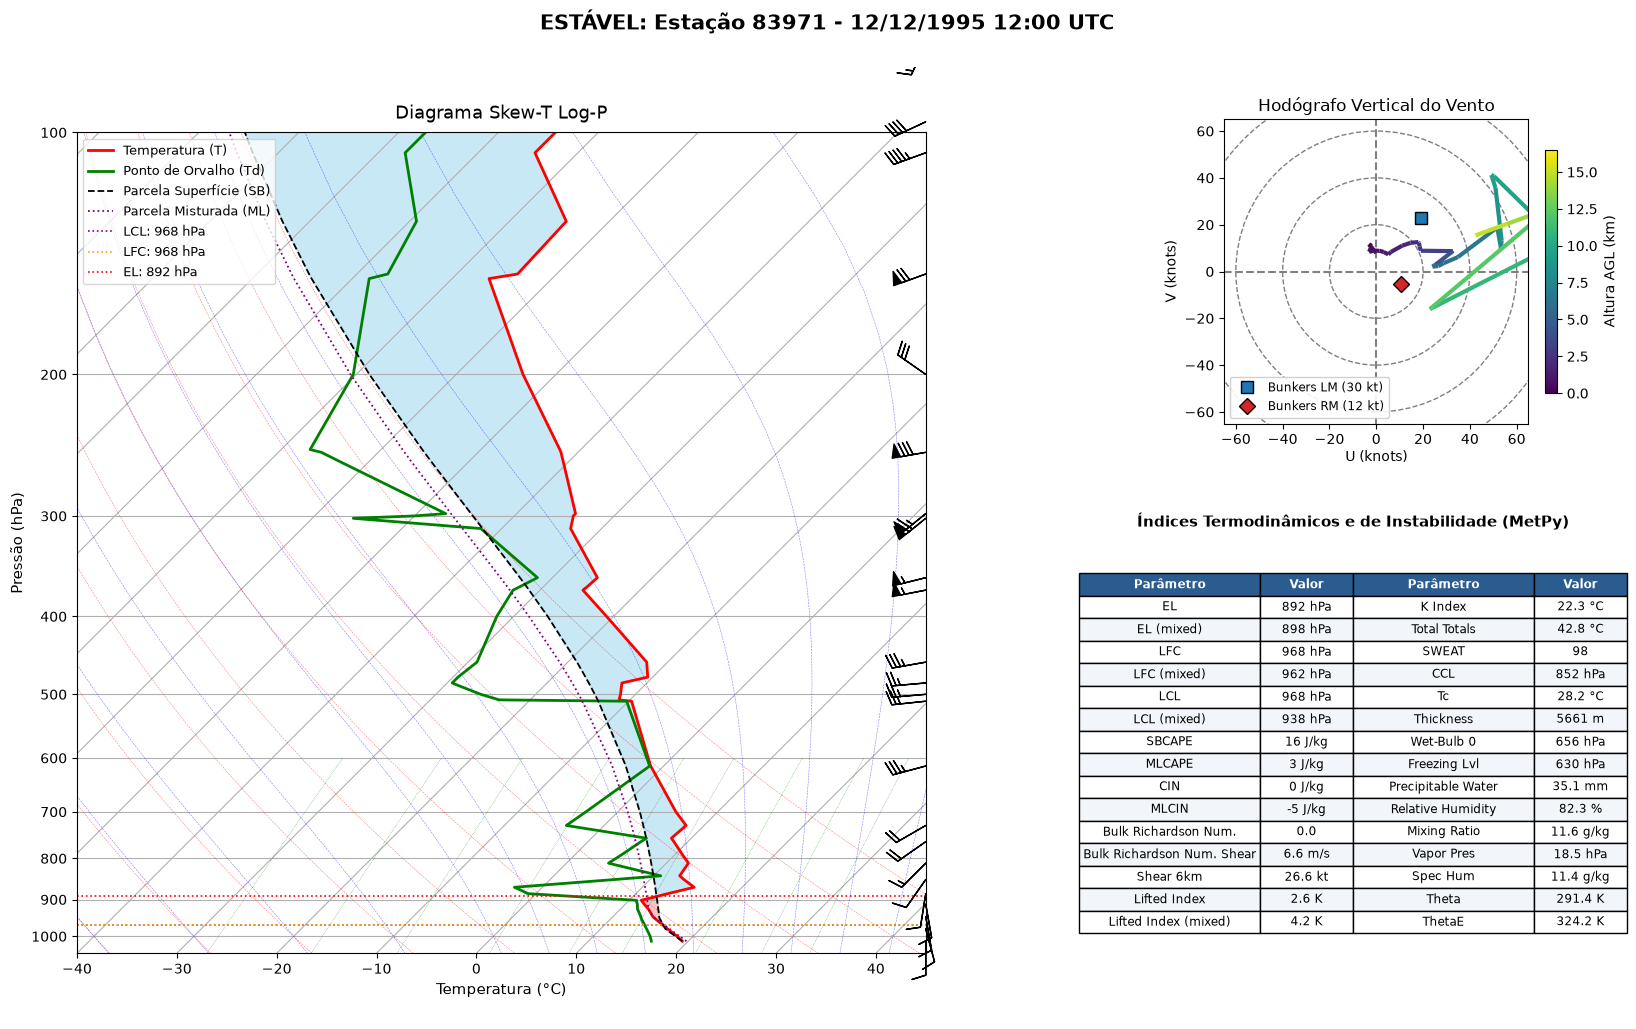

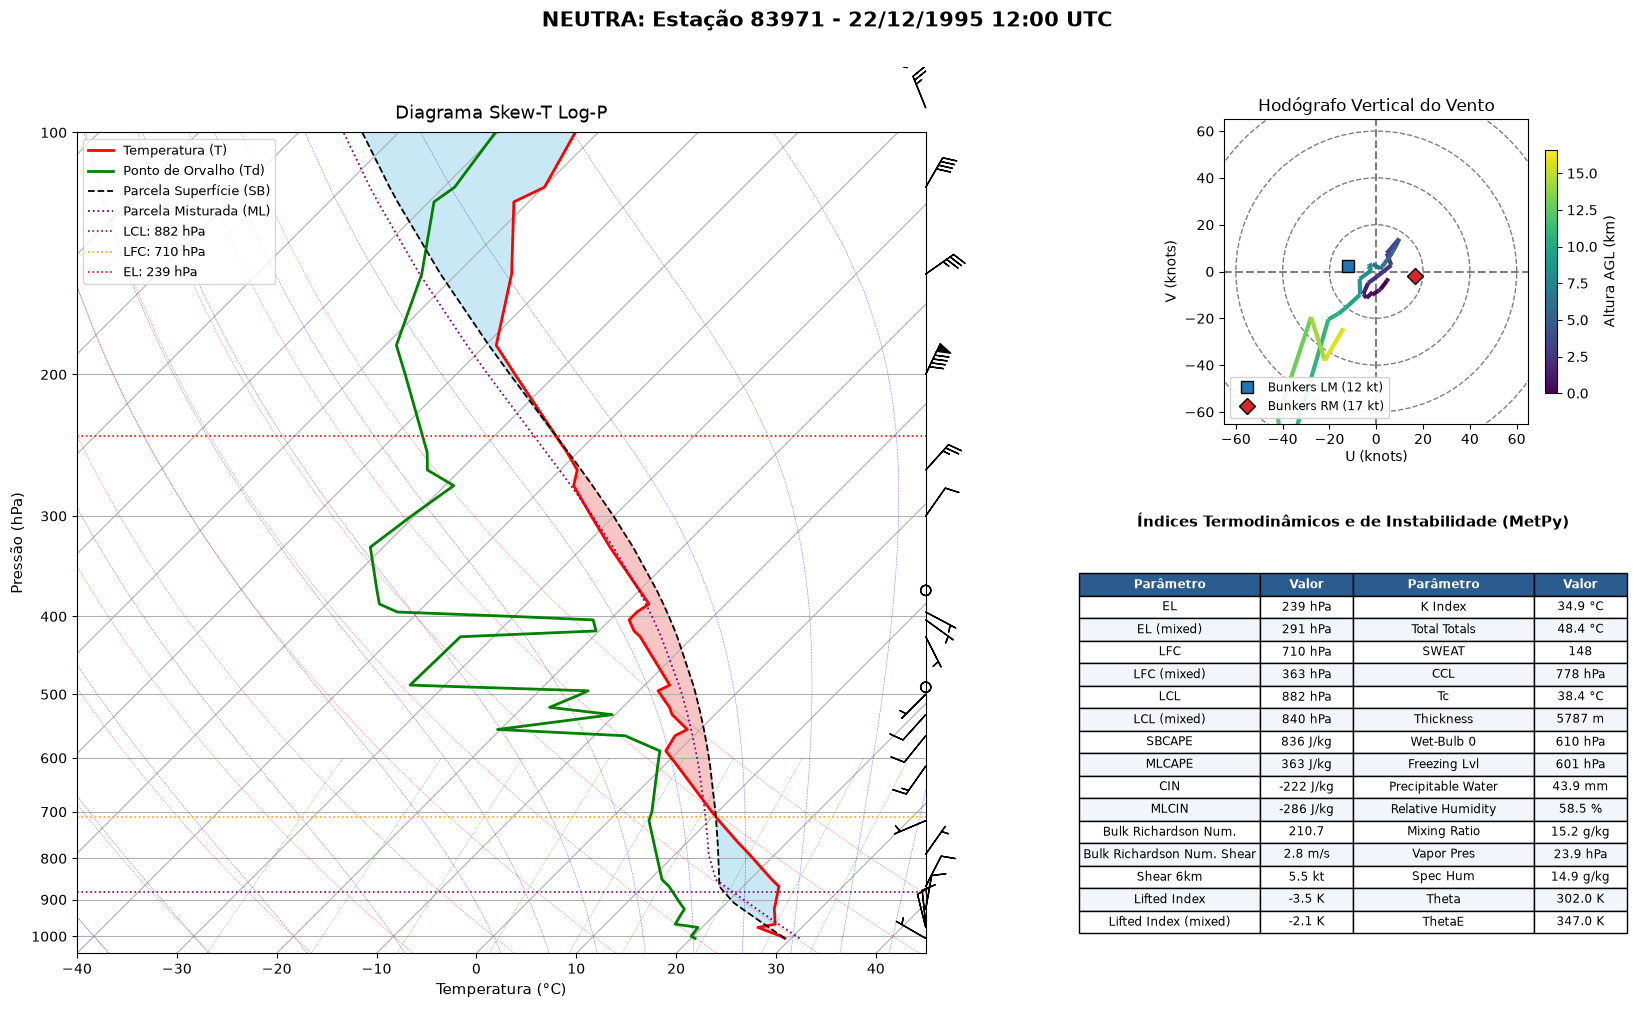

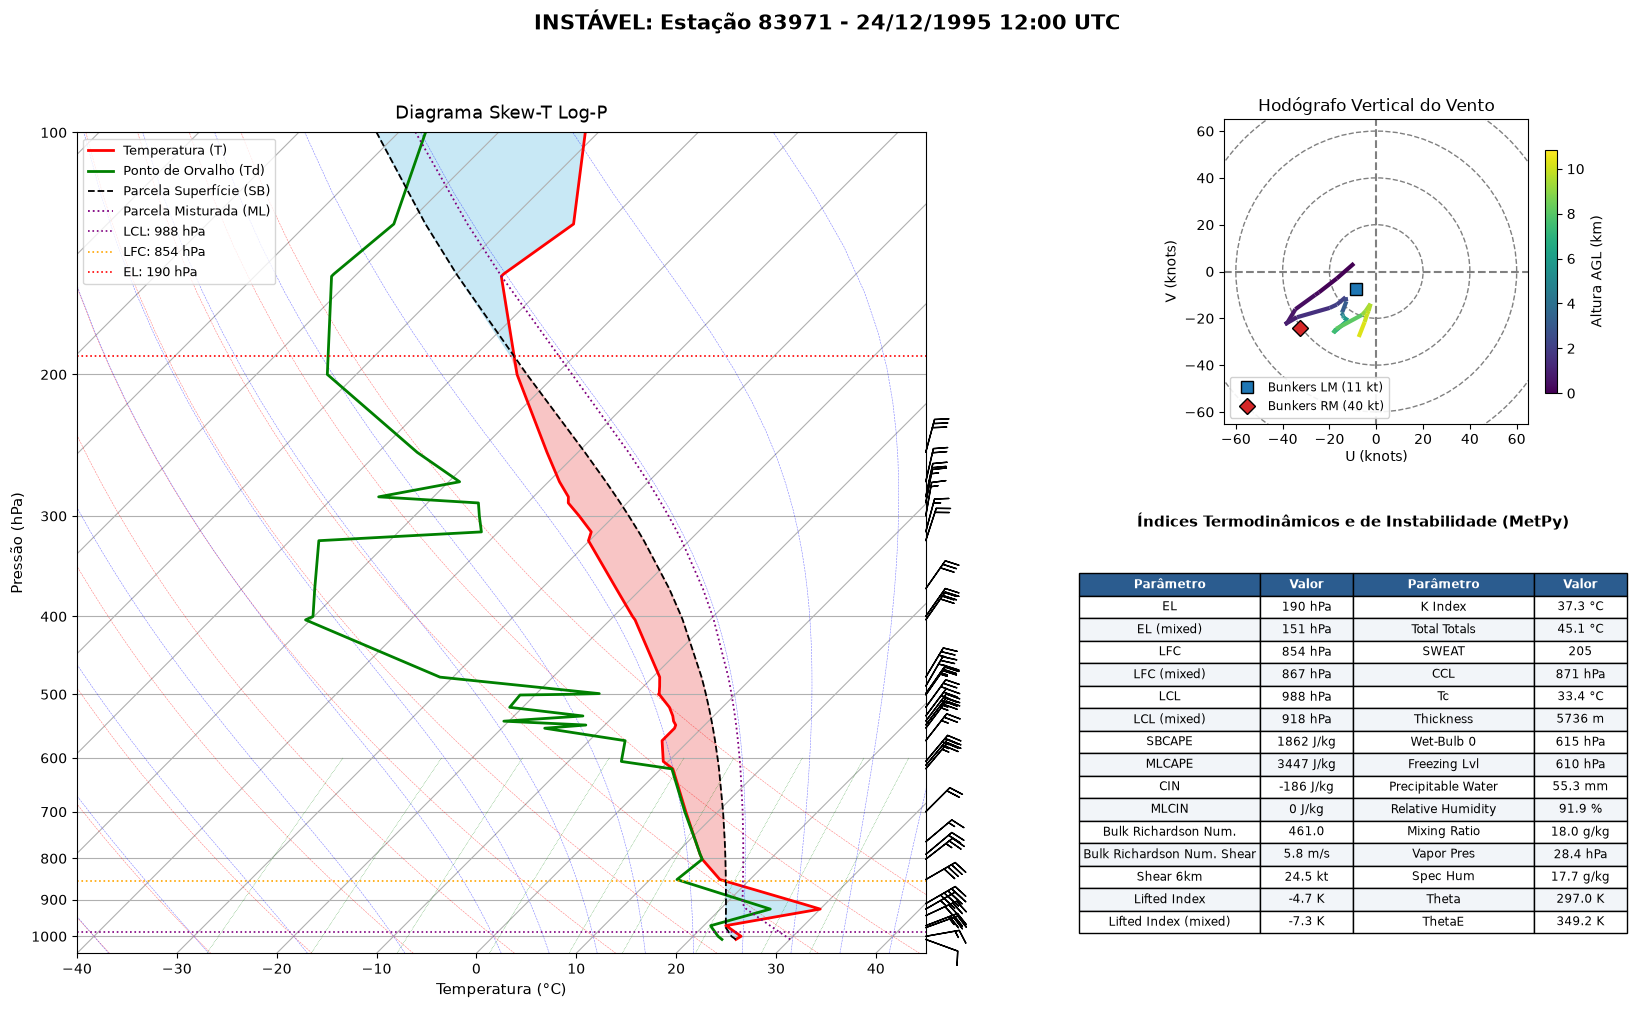

In [6]:
for k, c in enumerate(CASOS):
    P = c['perfil']
    I = c['indices_num']
    has_w = P['has_w']
    
    fig = plt.figure(figsize=(20, 11))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.55, 1.0], height_ratios=[1.0, 1.4], wspace=0.22, hspace=0.32)

    # 1. Diagrama Skew-T Log-P (Coluna esquerda, ocupando ambas as linhas)
    skew = SkewT(fig, rotation=45, subplot=gs[:, 0])
    skew.plot(P['p'], P['T'], 'r', lw=2, label='Temperatura (T)')
    skew.plot(P['p'], P['Td'], 'g', lw=2, label='Ponto de Orvalho (Td)')
    skew.plot(P['p'], P['prof_sb'], 'k--', lw=1.3, label='Parcela Superfície (SB)')
    skew.plot(P['p'], P['prof_ml'], color='purple', ls=':', lw=1.3, label='Parcela Misturada (ML)')

    skew.shade_cape(P['p'], P['T'], P['prof_sb'], color='lightcoral', alpha=0.45)
    skew.shade_cin(P['p'], P['T'], P['prof_sb'], color='skyblue', alpha=0.45)

    if hasattr(P['lcl_sb'][0], 'm') and not np.isnan(P['lcl_sb'][0].m):
        skew.ax.axhline(P['lcl_sb'][0], color='purple', ls=':', lw=1.2, label=f"LCL: {P['lcl_sb'][0]:.0f~P}")
    if hasattr(P['lfc_sb'][0], 'm') and not np.isnan(P['lfc_sb'][0].m):
        skew.ax.axhline(P['lfc_sb'][0], color='orange', ls=':', lw=1.2, label=f"LFC: {P['lfc_sb'][0]:.0f~P}")
    if hasattr(P['el_sb'][0], 'm') and not np.isnan(P['el_sb'][0].m):
        skew.ax.axhline(P['el_sb'][0], color='red', ls=':', lw=1.2, label=f"EL: {P['el_sb'][0]:.0f~P}")

    if has_w.any():
        passo = max(1, has_w.sum() // 25)
        p_barb = P['p'][has_w][::passo]
        u_barb = (P['u'][has_w][::passo]).to('knots')
        v_barb = (P['v'][has_w][::passo]).to('knots')
        skew.plot_barbs(p_barb, u_barb, v_barb)

    skew.plot_dry_adiabats(lw=0.4, color='brown', ls='--')
    skew.plot_moist_adiabats(lw=0.4, color='blue', ls='--')
    skew.plot_mixing_lines(lw=0.4, color='gray', ls=':')

    skew.ax.set_ylim(1050, 100)
    skew.ax.set_xlim(-40, 45)
    skew.ax.set_title("Diagrama Skew-T Log-P", fontsize=13, pad=10)
    skew.ax.set_xlabel('Temperatura (°C)', fontsize=11)
    skew.ax.set_ylabel('Pressão (hPa)', fontsize=11)
    skew.ax.legend(loc='upper left', fontsize=9)

    # 2. Hodógrafo menor (Canto superior direito)
    ax_hodo = fig.add_subplot(gs[0, 1])
    hodo = Hodograph(ax_hodo, component_range=65.)
    hodo.add_grid(increment=20, color='gray', linestyle='--')

    sel_hodo = has_w & (P['p'].m >= 100)
    if sel_hodo.any():
        u_kt = P['u'][sel_hodo].to('knots').m
        v_kt = P['v'][sel_hodo].to('knots').m
        h_km = P['h'][sel_hodo].to('km').m
        l = hodo.plot_colormapped(u_kt, v_kt, h_km, cmap='viridis')
        cbar = plt.colorbar(l, ax=ax_hodo, label='Altura AGL (km)', shrink=0.8, pad=0.03)
        # Movimento de tempestade de Bunkers: LM (left-mover, ciclônico no Hemisfério Sul) e RM (right-mover)
        lm, rm = P['bunkers_lm'], P['bunkers_rm']
        if np.isfinite(lm[0].m):
            u_lm, v_lm = lm[0].to('knots').m, lm[1].to('knots').m
            u_rm, v_rm = rm[0].to('knots').m, rm[1].to('knots').m
            ax_hodo.plot(u_lm, v_lm, 's', color='tab:blue', ms=9, mec='k',
                         label=f"Bunkers LM ({np.hypot(u_lm, v_lm):.0f} kt)")
            ax_hodo.plot(u_rm, v_rm, 'D', color='tab:red', ms=8, mec='k',
                         label=f"Bunkers RM ({np.hypot(u_rm, v_rm):.0f} kt)")
            ax_hodo.legend(loc='lower left', fontsize=8.5, framealpha=0.9)

    ax_hodo.set_title("Hodógrafo Vertical do Vento", fontsize=12)
    ax_hodo.set_xlabel('U (knots)', fontsize=10, labelpad=2)
    ax_hodo.set_ylabel('V (knots)', fontsize=10)

    # 3. Tabela completa com os 30 índices solicitados (Canto inferior direito)
    ax_table = fig.add_subplot(gs[1, 1])
    ax_table.axis('off')

    fmt_p = lambda v, u: f"{v:.0f} {u}".strip() if (v is not None and not np.isnan(v)) else "n/d"
    fmt_1 = lambda v, u: f"{v:.1f} {u}".strip() if (v is not None and not np.isnan(v)) else "n/d"

    col1 = [
        ("EL", fmt_p(I['EL'], "hPa")),
        ("EL (mixed)", fmt_p(I['EL (mixed)'], "hPa")),
        ("LFC", fmt_p(I['LFC'], "hPa")),
        ("LFC (mixed)", fmt_p(I['LFC (mixed)'], "hPa")),
        ("LCL", fmt_p(I['LCL'], "hPa")),
        ("LCL (mixed)", fmt_p(I['LCL (mixed)'], "hPa")),
        ("SBCAPE", fmt_p(I['SBCAPE'], "J/kg")),
        ("MLCAPE", fmt_p(I['MLCAPE'], "J/kg")),
        ("CIN", fmt_p(I['CIN'], "J/kg")),
        ("MLCIN", fmt_p(I['MLCIN'], "J/kg")),
        ("Bulk Richardson Num.", fmt_1(I['Bulk Richardson Num.'], "")),
        ("Bulk Richardson Num. Shear", fmt_1(I['Bulk Richardson Num. Shear'], "m/s")),
        ("Shear 6km", fmt_1(I['Shear 6km'], "kt")),
        ("Lifted Index", fmt_1(I['Lifted Index'], "K")),
        ("Lifted Index (mixed)", fmt_1(I['Lifted Index (mixed)'], "K")),
    ]

    col2 = [
        ("K Index", fmt_1(I['K Index'], "°C")),
        ("Total Totals", fmt_1(I['Total Totals'], "°C")),
        ("SWEAT", fmt_p(I['SWEAT'], "")),
        ("CCL", fmt_p(I['CCL'], "hPa")),
        ("Tc", fmt_1(I['Tc'], "°C")),
        ("Thickness", fmt_p(I['Thickness'], "m")),
        ("Wet-Bulb 0", fmt_p(I['Wet-Bulb 0'], "hPa")),
        ("Freezing Lvl", fmt_p(I['Freezing Lvl'], "hPa")),
        ("Precipitable Water", fmt_1(I['Precipitable Water'], "mm")),
        ("Relative Humidity", fmt_1(I['Relative Humidity'], "%")),
        ("Mixing Ratio", fmt_1(I['Mixing Ratio'], "g/kg")),
        ("Vapor Pres", fmt_1(I['Vapor Pres'], "hPa")),
        ("Spec Hum", fmt_1(I['Spec Hum'], "g/kg")),
        ("Theta", fmt_1(I['Theta'], "K")),
        ("ThetaE", fmt_1(I['ThetaE'], "K")),
    ]

    table_rows = []
    for (p1, v1), (p2, v2) in zip(col1, col2):
        table_rows.append([p1, v1, p2, v2])

    tbl = ax_table.table(cellText=table_rows, colLabels=['Parâmetro', 'Valor', 'Parâmetro', 'Valor'],
                         colWidths=[0.33, 0.17, 0.33, 0.17], loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1.0, 1.35)

    for (row, col_idx), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#2b5c8f')
            cell.set_text_props(color='white', weight='bold')
        else:
            if row % 2 == 0:
                cell.set_facecolor('#f2f5f9')

    ax_table.set_title("Índices Termodinâmicos e de Instabilidade (MetPy)", fontsize=11, pad=10, weight='bold')

    fig.suptitle(f"{c['regime']}: Estação {c['station']} - {c['date']:%d/%m/%Y %H:00} UTC", fontsize=15, weight='bold', y=0.98)
    tag = c['regime'].lower().replace('á', 'a')
    out_name = os.path.join(PASTA_SAIDA, f'fig_sounding_{k + 1}_{tag}.png')
    plt.savefig(out_name, dpi=150, bbox_inches='tight')
    plt.show()

### 5. Comparação dos Perfis Verticais

Perfis verticais das temperaturas potenciais em função da pressão até o nível de $200\text{ hPa}$:
* **$\theta$ (Temperatura Potencial):** Estabilidade estática em ar não saturado. Aumento de $\theta$ com a altitude ($\partial\theta/\partial z > 0$) caracteriza estabilidade estática seca.
* **$\theta_e$ (Temperatura Potencial Equivalente):** Decréscimo de $\theta_e$ com a altitude ($\partial\theta_e/\partial z < 0$) indica instabilidade potencial convectiva.
* **$\theta_{es}$ (Temperatura Potencial Equivalente de Saturação):** Decréscimo de $\theta_{es}$ com a altitude indica instabilidade condicional.

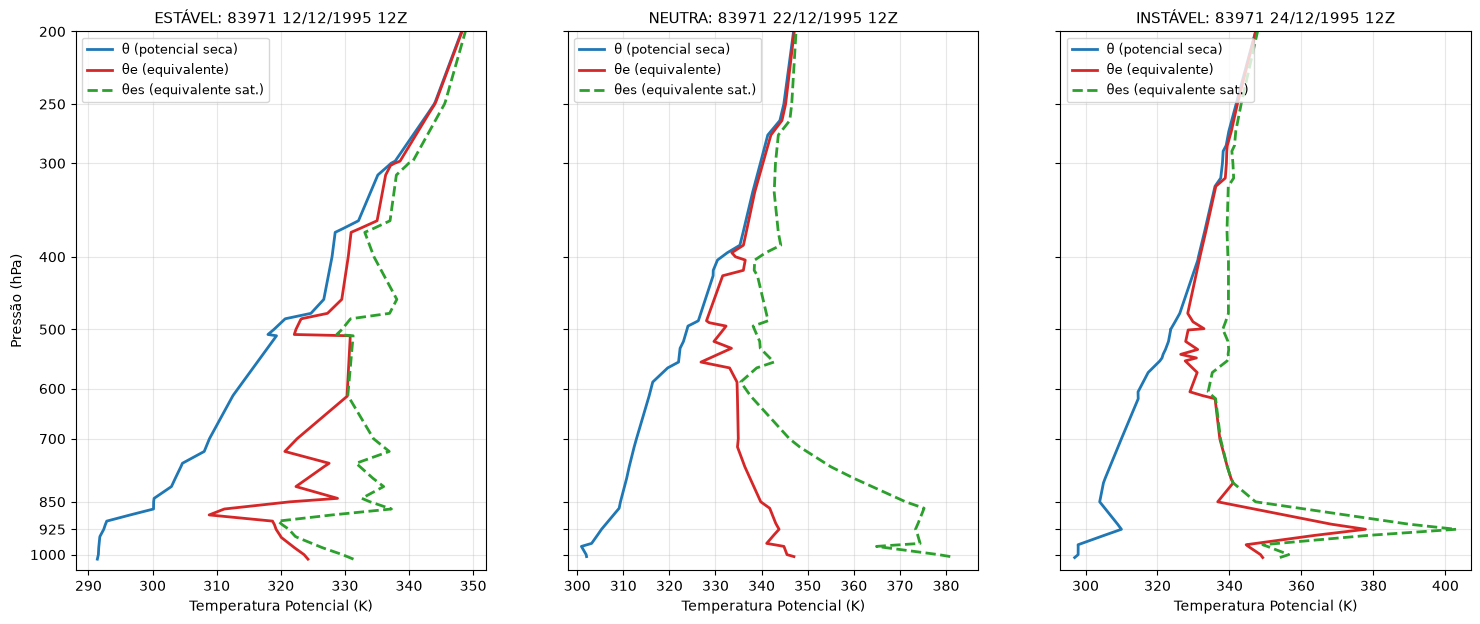

In [7]:
P_TOPO = 200
fig, axs = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for ax, c in zip(axs, CASOS):
    P = c['perfil']
    sel = P['p'].m >= P_TOPO
    
    th = P['theta'].m[sel]
    the = P['thetae'].m[sel]
    thes = P['thetas'].m[sel]
    pp = P['p'].m[sel]
    
    ax.plot(th, pp, color='tab:blue', lw=2, label='θ (potencial seca)')
    ax.plot(the, pp, color='tab:red', lw=2, label='θe (equivalente)')
    ax.plot(thes, pp, color='tab:green', lw=2, ls='--', label='θes (equivalente sat.)')
    
    ax.set_yscale('log')
    ax.set_ylim(1050, P_TOPO)
    
    # Ajuste dinâmico individual da escala horizontal para evitar cortes nos extremos
    vals = np.concatenate([th, the, thes])
    x_min = np.floor(np.nanmin(vals) / 5) * 5 - 2
    x_max = np.ceil(np.nanmax(vals) / 5) * 5 + 2
    ax.set_xlim(x_min, x_max)
    
    tk = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200]
    ax.set_yticks(tk)
    ax.set_yticklabels(map(str, tk))
    ax.minorticks_off()
    ax.grid(alpha=0.3)
    ax.set_xlabel('Temperatura Potencial (K)')
    ax.set_title(c['rotulo'], fontsize=11)
    ax.legend(loc='upper left', fontsize=9)

axs[0].set_ylabel('Pressão (hPa)')
plt.savefig(os.path.join(PASTA_SAIDA, 'fig_perfis_theta_triplice.png'), dpi=150, bbox_inches='tight')
plt.show()

### 6. Estabilidade Estática: Frequência de Brunt-Väisälä ($N^2$) e Parâmetro $S$

Perfis de estabilidade calculados até $200\text{ hPa}$ em escala logarítmica de pressão:
* **Frequência de Brunt-Väisälä ao quadrado ($N^2$):** $N^2 > 0$ indica estratificação estaticamente estável. Camadas com $N^2 < 0$ indicam instabilidade estática (gradiente superadiabático).
* **Parâmetro de Estabilidade Estática ($S = -\frac{T}{\theta}\frac{\partial\theta}{\partial p}$):** Medida da resistência do perfil ao deslocamento vertical em coordenadas isobáricas ($K/\text{hPa}$).

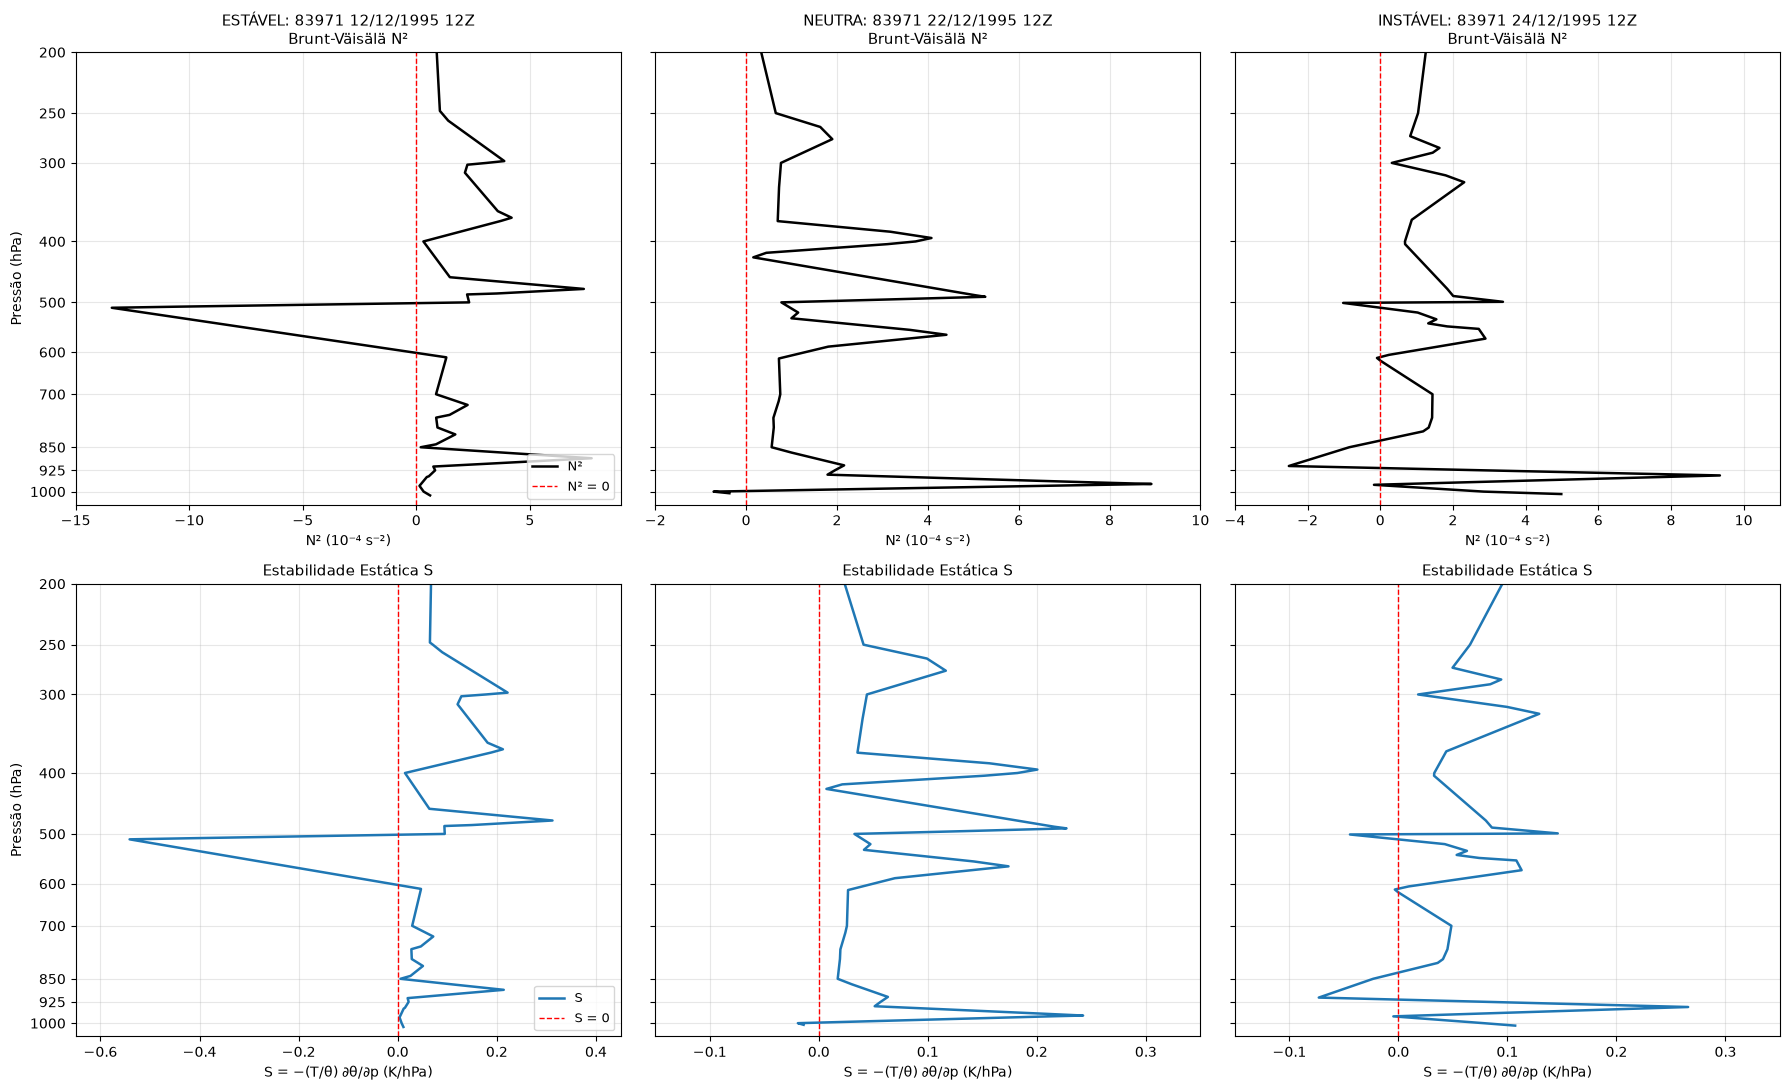

In [8]:
P_TOPO = 200
fig, axs = plt.subplots(2, 3, figsize=(18, 11), sharey=True)

for j, c in enumerate(CASOS):
    P = c['perfil']
    sel = P['p'].m >= P_TOPO
    pp = P['p'].m[sel]
    n2_vals = P['N2'][sel] * 1e4
    s_vals = P['S'][sel]
    
    # Linha 1: N²
    ax_n2 = axs[0, j]
    ax_n2.plot(n2_vals, pp, color='black', lw=1.8, label='N²')
    ax_n2.axvline(0, color='red', ls='--', lw=1, label='N² = 0')
    ax_n2.set_yscale('log')
    ax_n2.set_ylim(1050, P_TOPO)
    
    # Limites calculados individualmente para cada caso
    n2_min = min(-1.0, np.floor(np.nanmin(n2_vals)) - 1.0)
    n2_max = max(5.0, np.ceil(np.nanmax(n2_vals)) + 1.0)
    ax_n2.set_xlim(n2_min, n2_max)
    ax_n2.grid(alpha=0.3)
    ax_n2.set_title(f"{c['rotulo']}\nBrunt-Väisälä N²", fontsize=11)
    ax_n2.set_xlabel('N² (10⁻⁴ s⁻²)')
    if j == 0:
        ax_n2.set_ylabel('Pressão (hPa)')
        ax_n2.legend(loc='lower right', fontsize=9)
        
    # Linha 2: Parâmetro S
    ax_s = axs[1, j]
    ax_s.plot(s_vals, pp, color='tab:blue', lw=1.8, label='S')
    ax_s.axvline(0, color='red', ls='--', lw=1, label='S = 0')
    ax_s.set_yscale('log')
    ax_s.set_ylim(1050, P_TOPO)
    
    s_min = min(-0.05, np.floor(np.nanmin(s_vals) * 10) / 10 - 0.05)
    s_max = max(0.2, np.ceil(np.nanmax(s_vals) * 10) / 10 + 0.05)
    ax_s.set_xlim(s_min, s_max)
    ax_s.grid(alpha=0.3)
    ax_s.set_title("Estabilidade Estática S", fontsize=11)
    ax_s.set_xlabel('S = −(T/θ) ∂θ/∂p (K/hPa)')
    if j == 0:
        ax_s.set_ylabel('Pressão (hPa)')
        ax_s.legend(loc='lower right', fontsize=9)

tk = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200]
for row in axs:
    for ax in row:
        ax.set_yticks(tk)
        ax.set_yticklabels(map(str, tk))
        ax.minorticks_off()

plt.tight_layout()
plt.savefig(os.path.join(PASTA_SAIDA, 'fig_3_soundings_profiles_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7. Matrizes de Flutuabilidade de Kerry Emanuel

Diferença de temperatura de densidade ($\Delta T_{\rho} = T_{\rho,\text{parcela}} - T_{\rho,\text{ambiente}}$) em função do nível de origem da parcela (eixo horizontal) e do nível de elevação atingido (eixo vertical):
* **Valores positivos (vermelho):** Flutuabilidade positiva ($\Delta T_{\rho} > 0$).
* **Valores negativos (azul):** Flutuabilidade negativa e inibição ($\Delta T_{\rho} < 0$).
* **Linha contínua preta ($0\text{ K}$):** Nível de flutuabilidade neutra.
* **Ascensão Reversível:** Toda água condensada permanece na parcela, reduzindo a flutuabilidade devido ao peso da fase líquida.
* **Ascensão Pseudoadiabática:** Precipitação instantânea do condensado, gerando maior flutuabilidade líquida.

In [9]:
def le_cape_out(arq='cape.out'):
    linhas = [l.split() for l in open(arq, encoding='latin1') if re.match(r'^\s*-?\d+\.\d', l)]
    return pd.DataFrame([[float(x) for x in l[:8]] for l in linhas],
                        columns=['p_origem', 'PA_rev', 'PA_pse', 'NA_rev', 'NA_pse', 'CAPE_rev', 'CAPE_pse', 'DCAPE'])

def plota_emanuel(ax, X, Y, campo, amp):
    Z = np.where(Y < X, campo, np.nan)
    cf = ax.contourf(X, Y, Z, levels=np.arange(-amp, amp + 0.25, 0.5), cmap='RdBu_r',
                     vmin=-amp, vmax=amp, extend='both')
    cs = ax.contour(X, Y, Z, levels=[v for v in np.arange(-amp, amp + 0.1, 2) if v != 0], colors='k', linewidths=0.7)
    ax.clabel(cs, fmt='%d', fontsize=8)
    cz = ax.contour(X, Y, Z, levels=[0], colors='k', linewidths=2)
    ax.clabel(cz, fmt='0', fontsize=9)
    ax.set_xlim(X.max(), X.min())
    ax.set_ylim(Y.max(), 100)
    ax.set_xlabel('Pressão de Origem (hPa)')
    ax.set_ylabel('Pressão de Elevação (hPa)')
    ax.grid(alpha=0.3, ls=':')
    return cf

EM = {}
exe_path = os.path.abspath('wyoming.exe')

for c in CASOS:
    pasta = f"emanuel_{c['date']:%Y%m%d_%H}"
    os.makedirs(pasta, exist_ok=True)
    escreve_sounding_txt(c['df'], c['station'], c['date'], os.path.join(pasta, 'sounding.txt'))
    
    r = subprocess.run([exe_path], cwd=pasta, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f"wyoming.exe falhou para {c['rotulo']} (código {r.returncode}):\n{r.stdout}\n{r.stderr}")
        
    E = dict(
        p=np.loadtxt(f'{pasta}/p.out'),
        porig=np.loadtxt(f'{pasta}/porig.out'),
        rev=np.loadtxt(f'{pasta}/tdifrev.out'),
        pse=np.loadtxt(f'{pasta}/tdifpseudo.out'),
        cape=le_cape_out(f'{pasta}/cape.out')
    )
    E['X'], E['Y'] = np.meshgrid(E['porig'], E['p'])
    EM[c['rotulo']] = E

print("Execução do modelo de Emanuel concluída.")

Execução do modelo de Emanuel concluída.


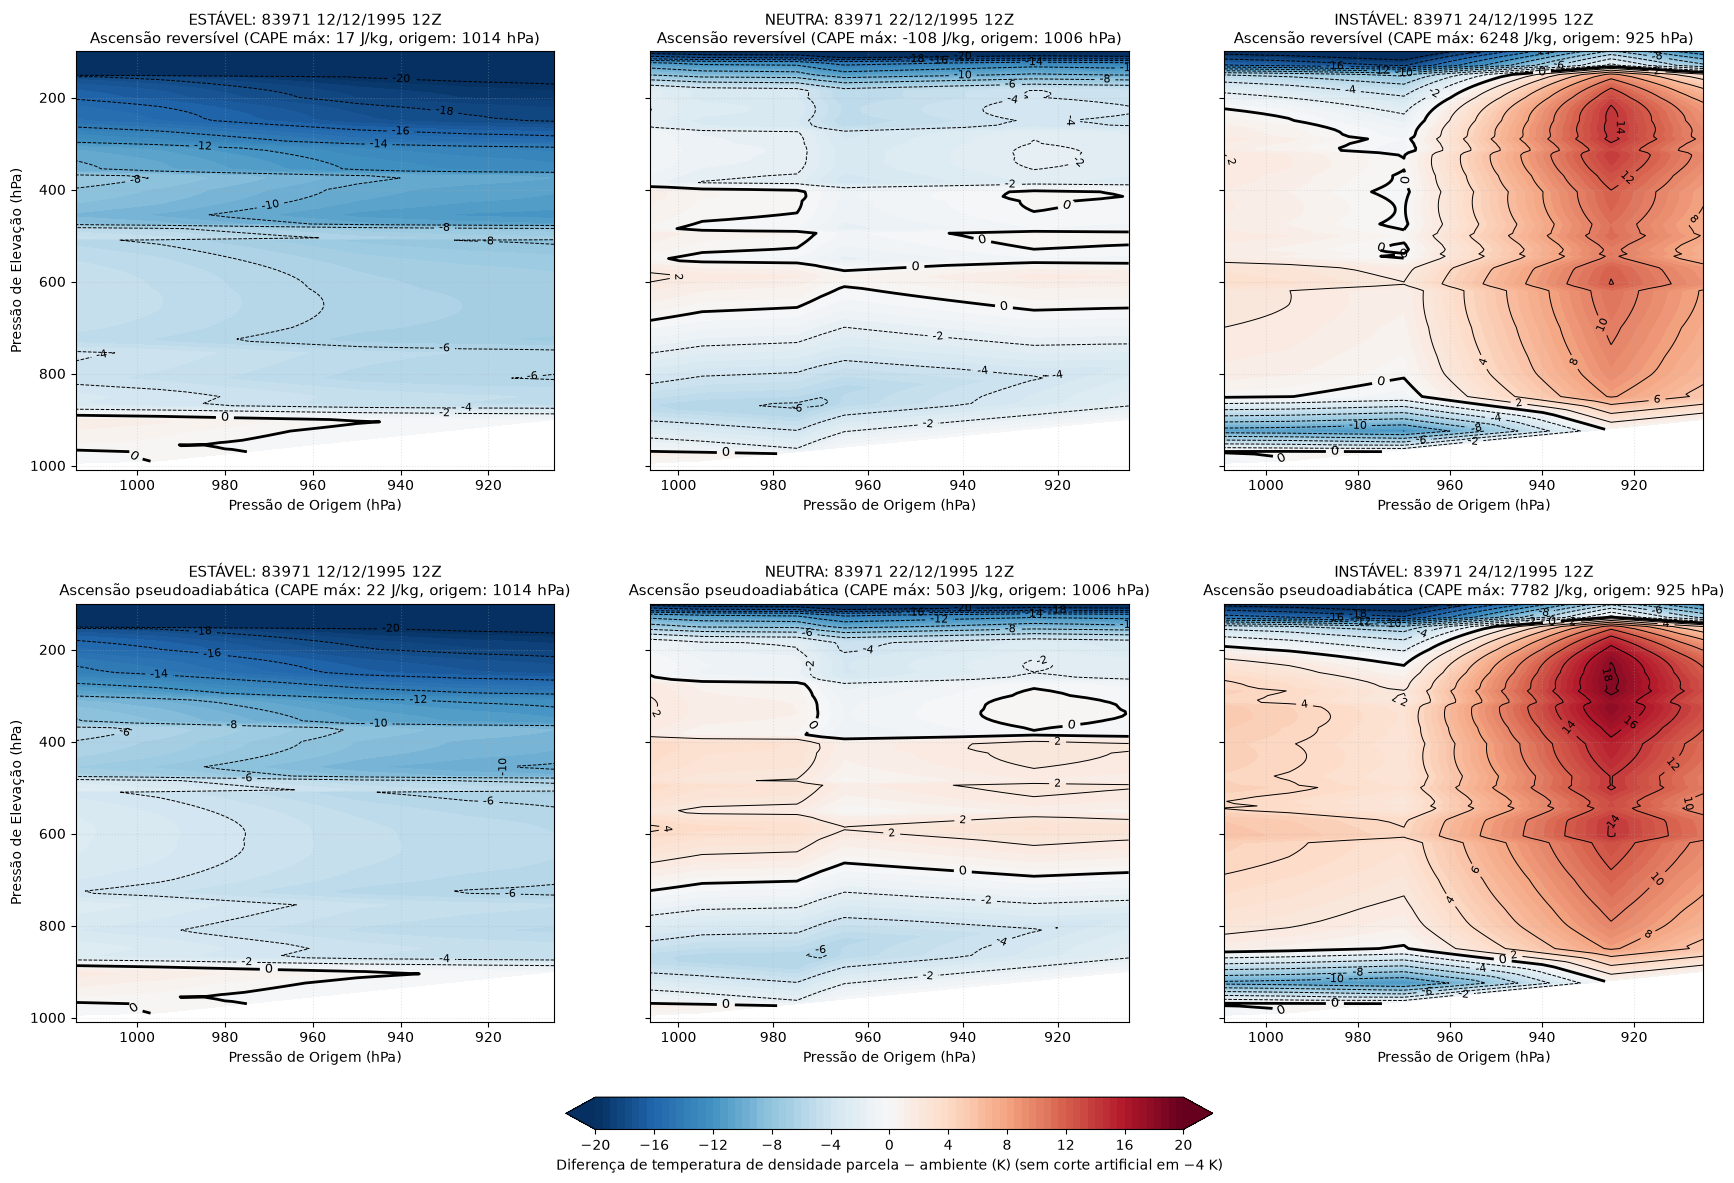

In [10]:
amp = 6.0
for E in EM.values():
    vis = (E['Y'] < E['X']) & (E['Y'] >= 100)
    amp = max(amp, 2 * np.ceil(max(np.nanmax(E['rev'][vis]), np.nanmax(E['pse'][vis])) / 2))

fig, axs = plt.subplots(2, 3, figsize=(21, 14), sharey=True, gridspec_kw=dict(hspace=0.32))

for j, (rot, E) in enumerate(EM.items()):
    for i, (campo, nome) in enumerate(((E['rev'], 'reversível'), (E['pse'], 'pseudoadiabática'))):
        ax = axs[i, j]
        cf = plota_emanuel(ax, E['X'], E['Y'], campo, amp)
        col = 'CAPE_pse' if i else 'CAPE_rev'
        k = E['cape'][col].idxmax()
        ax.set_title(f"{rot}\nAscensão {nome} (CAPE máx: {E['cape'].loc[k, col]:.0f} J/kg, origem: {E['cape'].loc[k, 'p_origem']:.0f} hPa)", fontsize=10.5)
        if j > 0:
            ax.set_ylabel('')

cbar = fig.colorbar(cf, ax=axs, orientation='horizontal', fraction=0.03, pad=0.07, ticks=np.arange(-amp, amp + 1, 2 if amp <= 10 else 4),
                    label='Diferença de temperatura de densidade parcela − ambiente (K)' +
                          ('' if CORTE_EMANUEL else ' (sem corte artificial em −4 K)'))

plt.savefig(os.path.join(PASTA_SAIDA, 'fig_3_soundings_emanuel_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

#### 7.1 Matrizes de flutuabilidade de Emanuel por sondagem

As mesmas matrizes da figura anterior (mesmos dados de `wyoming.f` e mesma escala de cores), uma figura por sondagem: estável, neutra e instável.

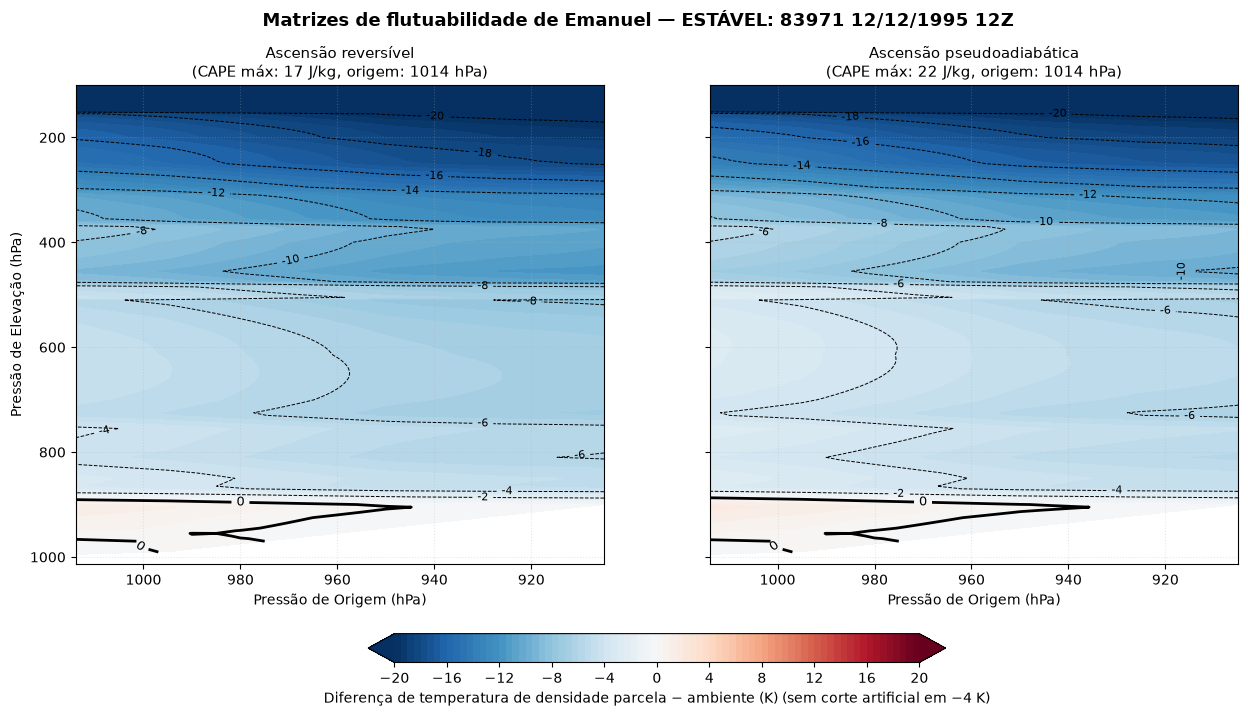

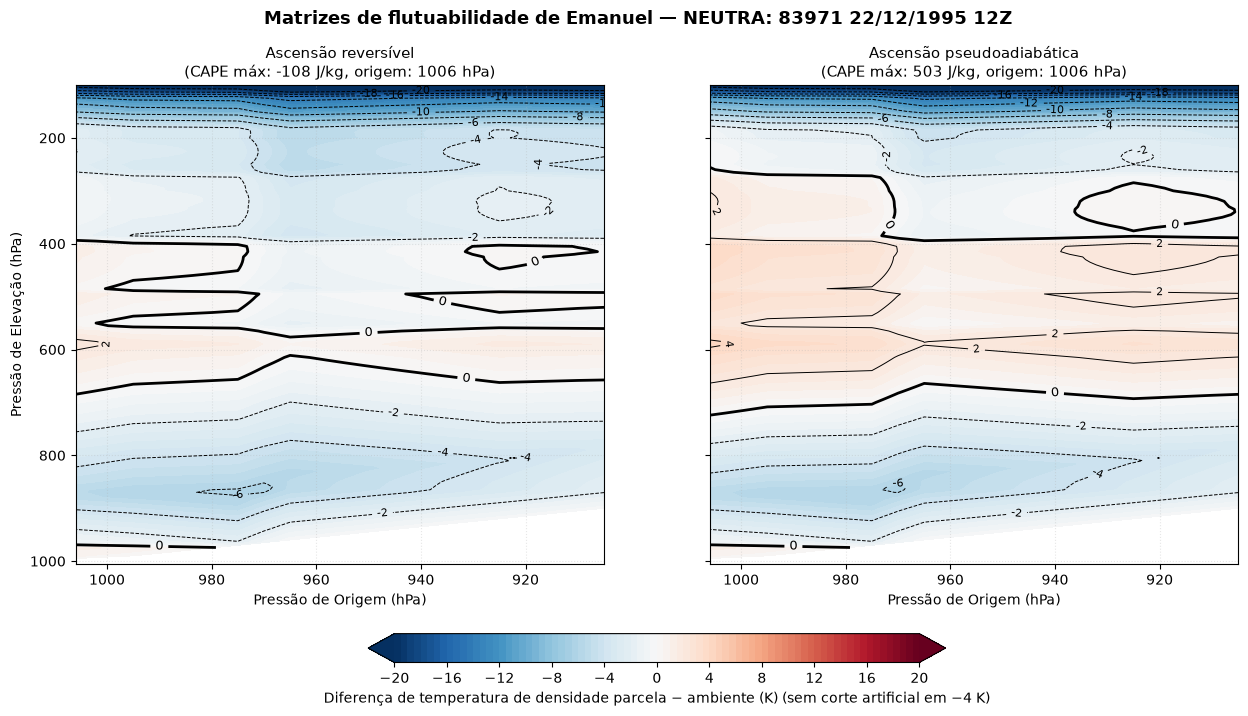

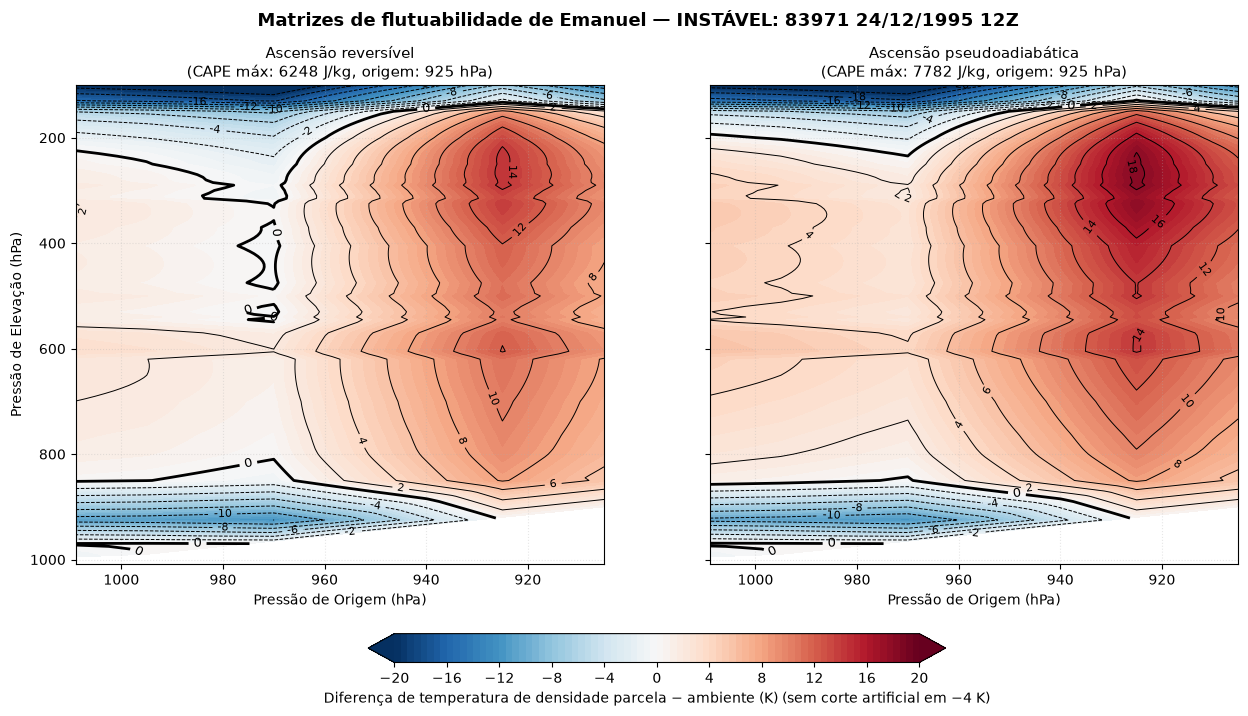

In [11]:
for c in CASOS:
    E = EM[c['rotulo']]
    fig, axs2 = plt.subplots(1, 2, figsize=(15, 7.5), sharey=True)
    for ax, (campo, nome, col) in zip(axs2, ((E['rev'], 'reversível', 'CAPE_rev'), (E['pse'], 'pseudoadiabática', 'CAPE_pse'))):
        cf = plota_emanuel(ax, E['X'], E['Y'], campo, amp)
        k = E['cape'][col].idxmax()
        ax.set_title(f"Ascensão {nome}\n(CAPE máx: {E['cape'].loc[k, col]:.0f} J/kg, origem: {E['cape'].loc[k, 'p_origem']:.0f} hPa)", fontsize=11)
    axs2[1].set_ylabel('')
    fig.colorbar(cf, ax=axs2, orientation='horizontal', fraction=0.05, pad=0.12, ticks=np.arange(-amp, amp + 1, 2 if amp <= 10 else 4),
                 label='Diferença de temperatura de densidade parcela − ambiente (K)' +
                       ('' if CORTE_EMANUEL else ' (sem corte artificial em −4 K)'))
    fig.suptitle(f"Matrizes de flutuabilidade de Emanuel — {c['rotulo']}", fontsize=13, weight='bold')
    plt.savefig(os.path.join(PASTA_SAIDA, f"emanuel_{c['date']:%Y%m%d}.png"), dpi=150, bbox_inches='tight')
    plt.show()


In [12]:
resumo_emanuel = pd.DataFrame({
    rot: {
        'CAPE reversível superfície (J/kg)': E['cape'].iloc[0]['CAPE_rev'],
        'CAPE pseudoadiabática superfície (J/kg)': E['cape'].iloc[0]['CAPE_pse'],
        'CAPE reversível máxima (J/kg)': E['cape']['CAPE_rev'].max(),
        'CAPE pseudoadiabática máxima (J/kg)': E['cape']['CAPE_pse'].max(),
        'Nível de origem da CAPE máxima (hPa)': E['cape'].loc[E['cape']['CAPE_pse'].idxmax(), 'p_origem'],
        'DCAPE máxima Emanuel (J/kg)': E['cape']['DCAPE'].max()
    }
    for rot, E in EM.items()
}).round(1)

display(resumo_emanuel)

# Tabela única de valores usada pelo site e pelos slides (mesmos números do notebook)
import json
saida = {}
for c in CASOS:
    saida[f"{c['date']:%Y%m%d}"] = {
        'regime': c['regime'], 'data': f"{c['date']:%d/%m/%Y %HZ}", 'fonte': c['fonte'],
        'indices_metpy': {k: (None if v is None or (isinstance(v, float) and np.isnan(v)) else round(float(v), 4))
                          for k, v in c['indices_num'].items()},
        'indices_wyoming': c['indices_wyoming'],
        'emanuel': {k: round(float(v), 1) for k, v in resumo_emanuel[c['rotulo']].items()},
    }
with open(os.path.join(PASTA_SAIDA, 'metricas_notebook.json'), 'w', encoding='utf-8') as f:
    json.dump(saida, f, ensure_ascii=False, indent=1)
print('Gravado:', os.path.join(PASTA_SAIDA, 'metricas_notebook.json'))

,ESTÁVEL: 83971 12/12/1995 12Z,NEUTRA: 83971 22/12/1995 12Z,INSTÁVEL: 83971 24/12/1995 12Z
CAPE reversível superfície (J/kg),16.9,-107.7,402.4
CAPE pseudoadiabática superfície (J/kg),22.5,503.4,1480.2
CAPE reversível máxima (J/kg),16.9,-107.7,6247.8
CAPE pseudoadiabática máxima (J/kg),22.5,503.4,7782.1
Nível de origem da CAPE máxima (hPa),1014.0,1006.0,925.0
DCAPE máxima Emanuel (J/kg),60.0,195.4,60.7


Gravado: metpack/metricas_notebook.json


### 8. Síntese dos Resultados para Apresentação

Pontos fundamentais para a discussão dos regimes:
* **Assinatura nos Diagramas Skew-T e Hodógrafos:**
  * No caso estável, verificar a proximidade entre a temperatura e o perfil adiabático com ausência de área positiva.
  * No caso instável, avaliar a espessura da camada de mistura úmida, a área de CAPE integrada até o Nível de Equilíbrio (EL) e o valor do Lifted Index.
  * No hodógrafo, analisar a intensidade do cisalhamento 0-6 km e a curvatura ciclônica em baixos níveis.
* **Conferência MetPy vs. Wyoming:**
  * Comparar os valores do MetPy com os publicados pelo Wyoming e explicar as diferenças (parcela usada, temperatura virtual, método de integração, unidade do vento no SWEAT).
* **Perfis Verticais de $\theta$, $\theta_e$ e $\theta_{es}$:**
  * Identificar camadas de decréscimo vertical de $\theta_e$ como indicativo de instabilidade potencial convectiva.
  * Contrastar a inclinação de $\theta$ em baixos níveis entre o regime estável (inversão térmica ou gradiente fortemente estável) e o regime instável.
* **Impacto do Carregamento de Água nas Matrizes de Emanuel:**
  * Comparar a redução sistemática de CAPE entre a ascensão pseudoadiabática e a reversível, decorrente da sobrecarga de água líquida condensada mantida na parcela.
  * Localizar o nível de pressão da parcela mais instável em relação à superfície.